In [ ]:
!pip install timm -q

import os, random, json
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error, cohen_kappa_score, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

In [ ]:
data_root = "/kaggle/input/datasets/khalidsiddiqui2003/dfu-dataset-annotated-into-4-classes/train"
grade_dirs = {"Grade 1": 0, "Grade 2": 1, "Grade 3": 2, "Grade 4": 3}  # 0-indexed for CORN

records = []
for grade_name, label in grade_dirs.items():
    grade_path = os.path.join(data_root, grade_name)
    for fname in os.listdir(grade_path):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            records.append({"path": os.path.join(grade_path, fname), "label": label})

df = pd.DataFrame(records)
print(df["label"].value_counts().sort_index())
print("Total:", len(df))

In [ ]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print(train_df["label"].value_counts().sort_index())

In [ ]:
IMG_SIZE = 224

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=25, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
    A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=15, val_shift_limit=10, p=0.3),  # mild, preserves diagnostic color
    A.CoarseDropout(max_holes=6, max_height=24, max_width=24, p=0.4),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

In [ ]:
class WoundDataset(Dataset):
    def __init__(self, df, transform):
        self.paths = df["path"].values
        self.labels = df["label"].values
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = np.array(Image.open(self.paths[idx]).convert("RGB"))
        img = self.transform(image=img)["image"]
        label = self.labels[idx]
        return img, label

from torch.utils.data import WeightedRandomSampler

train_ds = WoundDataset(train_df, train_transform)
val_ds = WoundDataset(val_df, eval_transform)
test_ds = WoundDataset(test_df, eval_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
NUM_CLASSES = 4
NUM_CORN_LOGITS = NUM_CLASSES - 1

# Class weights: upweight Grade 1 specifically, since it has the worst recall (28.6%)
# not based on class frequency, but based on observed difficulty
CLASS_WEIGHTS = torch.tensor([2.0, 1.2, 1.0, 1.0], device=device)  # Grade1, Grade2, Grade3, Grade4

def corn_label_from_class(labels, num_classes):
    batch_size = labels.size(0)
    corn_labels = torch.zeros(batch_size, num_classes - 1, device=labels.device)
    for i in range(num_classes - 1):
        corn_labels[:, i] = (labels > i).float()
    return corn_labels

def corn_loss_weighted(logits, labels, class_weights=CLASS_WEIGHTS):
    """
    CORN conditional training loss with per-sample class weighting.
    Each sample's contribution to the loss is scaled by its true class's weight,
    so misclassifying a Grade 1 sample costs more than misclassifying Grade 3/4.
    """
    corn_targets = corn_label_from_class(labels, NUM_CLASSES)
    sample_weights = class_weights[labels]  # shape (batch,), weight per sample based on true grade

    losses = []
    for i in range(NUM_CORN_LOGITS):
        mask = (labels >= i).float()  # only samples still 'in play' at this ordinal threshold
        if mask.sum() == 0:
            continue
        logit_i = logits[:, i]
        target_i = corn_targets[:, i]
        loss_i = F.binary_cross_entropy_with_logits(logit_i, target_i, reduction="none")

        weighted_loss_i = loss_i * mask * sample_weights
        losses.append(weighted_loss_i.sum() / (mask * sample_weights).sum())
    return torch.stack(losses).mean()

def corn_decode(logits):
    probas = torch.sigmoid(logits)
    predict = (probas > 0.5).sum(dim=1)
    return predict




In [ ]:
class WoundGradingModel(nn.Module):
    def __init__(self, backbone_name="resnetv2_50x1_bit.goog_in21k", num_corn_logits=3, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained, num_classes=0)
        feat_dim = self.backbone.num_features

        self.head = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, num_corn_logits)
        )

    def forward(self, x):
        feats = self.backbone(x)
        return self.head(feats)

model = WoundGradingModel().to(device)
print("Backbone feature dim:", model.backbone.num_features)

In [ ]:
def freeze_backbone(model, freeze=True):
    for param in model.backbone.parameters():
        param.requires_grad = not freeze

# start with backbone frozen (feature extraction phase)
freeze_backbone(model, freeze=True)

def build_optimizer(model, backbone_lr=1e-5, head_lr=1e-3):
    return AdamW([
        {"params": model.backbone.parameters(), "lr": backbone_lr},
        {"params": model.head.parameters(), "lr": head_lr}
    ], weight_decay=1e-4)

optimizer = build_optimizer(model)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-7)

In [ ]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            preds = corn_decode(logits).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    acc = accuracy_score(all_labels, all_preds)
    mae = mean_absolute_error(all_labels, all_preds)
    qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    return acc, mae, qwk, all_preds, all_labels

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = corn_loss_weighted(logits, labels)   # <-- weighted loss used here
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)

# ---- Phase 1: train head only, backbone frozen ----
PHASE1_EPOCHS = 8
best_qwk = -1
for epoch in range(PHASE1_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_acc, val_mae, val_qwk, _, _ = evaluate(model, val_loader)
    scheduler.step()
    print(f"[Phase1 Epoch {epoch}] loss={train_loss:.4f} val_acc={val_acc:.4f} val_mae={val_mae:.4f} val_qwk={val_qwk:.4f}")
    if val_qwk > best_qwk:
        best_qwk = val_qwk
        torch.save(model.state_dict(), "/kaggle/working/best_model_phase1.pth")

# ---- Phase 2: unfreeze backbone, fine-tune end-to-end at low LR ----
freeze_backbone(model, freeze=False)
optimizer = build_optimizer(model, backbone_lr=2e-6, head_lr=1e-4)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-8)

PHASE2_EPOCHS = 25
patience = 6
epochs_no_improve = 0

for epoch in range(PHASE2_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_acc, val_mae, val_qwk, _, _ = evaluate(model, val_loader)
    scheduler.step()
    print(f"[Phase2 Epoch {epoch}] loss={train_loss:.4f} val_acc={val_acc:.4f} val_mae={val_mae:.4f} val_qwk={val_qwk:.4f}")

    if val_qwk > best_qwk:
        best_qwk = val_qwk
        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered.")
            break 

In [ ]:
model.load_state_dict(torch.load("/kaggle/working/best_model.pth")) 
model.eval()   
 
def predict_with_tta(model, loader, n_tta=4):
    """Averages predictions over horizontal flip + original for a small robustness boost."""
    all_logits_sum = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            logits_sum = torch.zeros(imgs.size(0), NUM_CORN_LOGITS, device=device)
            logits_sum += torch.sigmoid(model(imgs))
            logits_sum += torch.sigmoid(model(torch.flip(imgs, dims=[3])))  # horizontal flip
            avg_probas = logits_sum / 2
            preds = (avg_probas > 0.5).sum(dim=1).cpu().numpy()
            all_logits_sum.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_logits_sum), np.array(all_labels)

test_preds, test_labels = predict_with_tta(model, test_loader)

test_acc = accuracy_score(test_labels, test_preds)
test_mae = mean_absolute_error(test_labels, test_preds)
test_qwk = cohen_kappa_score(test_labels, test_preds, weights="quadratic")

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test QWK: {test_qwk:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(test_labels, test_preds))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Grade 1","Grade 2","Grade 3","Grade 4"],
            yticklabels=["Grade 1","Grade 2","Grade 3","Grade 4"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix (Test Acc={test_acc:.3f}, QWK={test_qwk:.3f})")
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score

macro_f1 = f1_score(test_labels, test_preds, average="macro")
recall_per_grade = recall_score(test_labels, test_preds, average=None)
precision_per_grade = precision_score(test_labels, test_preds, average=None)
f1_per_grade = f1_score(test_labels, test_preds, average=None)

print(f"Macro F1: {macro_f1:.4f}\n")

grade_names = ["Grade 1", "Grade 2", "Grade 3", "Grade 4"]
for i, name in enumerate(grade_names):
    print(f"{name}: Precision={precision_per_grade[i]:.4f}  Recall={recall_per_grade[i]:.4f}  F1={f1_per_grade[i]:.4f}")

print("\nFull classification report:")
print(classification_report(test_labels, test_preds, target_names=grade_names, digits=4))

In [ ]:
def corn_decode_thresholds(logits, thresholds):
    """thresholds: list of 3 cutoffs, one per cumulative logit"""
    probas = torch.sigmoid(logits)
    preds = torch.zeros(probas.size(0), dtype=torch.long, device=probas.device)
    for i, t in enumerate(thresholds):
        preds += (probas[:, i] > t).long()
    return preds

def find_best_thresholds(model, val_loader, grid=np.arange(0.3, 0.71, 0.05)):
    """Grid search thresholds on validation set to maximize macro F1."""
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            all_logits.append(torch.sigmoid(logits).cpu())
            all_labels.append(labels)
    all_logits = torch.cat(all_logits).numpy()
    all_labels = torch.cat(all_labels).numpy()

    best_score = -1
    best_thresholds = [0.5, 0.5, 0.5]
    for t0 in grid:
        for t1 in grid:
            for t2 in grid:
                preds = np.zeros(len(all_labels), dtype=int)
                preds += (all_logits[:, 0] > t0).astype(int)
                preds += (all_logits[:, 1] > t1).astype(int)
                preds += (all_logits[:, 2] > t2).astype(int)
                score = f1_score(all_labels, preds, average="macro")
                if score > best_score:
                    best_score = score
                    best_thresholds = [t0, t1, t2]
    print(f"Best macro F1 on val: {best_score:.4f} with thresholds {best_thresholds}")
    return best_thresholds

best_thresholds = find_best_thresholds(model, val_loader)

**test thresholds**

In [ ]:
best_thresholds = find_best_thresholds(model, val_loader, grid=np.arange(0.3, 0.86, 0.025))

In [ ]:
best_thresholds = find_best_thresholds(model, val_loader, grid=np.arange(0.3, 0.995, 0.01))

In [ ]:
best_thresholds = [0.53, 0.9, 0.9]

In [ ]:
model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
model.eval()

all_logits, all_labels_list = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        all_logits.append(torch.sigmoid(logits).cpu())
        all_labels_list.append(labels)
all_logits = torch.cat(all_logits).numpy()
test_labels = torch.cat(all_labels_list).numpy()

test_preds = np.zeros(len(test_labels), dtype=int)
test_preds += (all_logits[:, 0] > best_thresholds[0]).astype(int)
test_preds += (all_logits[:, 1] > best_thresholds[1]).astype(int)
test_preds += (all_logits[:, 2] > best_thresholds[2]).astype(int)

test_acc = accuracy_score(test_labels, test_preds)
test_mae = mean_absolute_error(test_labels, test_preds)
test_qwk = cohen_kappa_score(test_labels, test_preds, weights="quadratic")
print(f"Calibrated Test Accuracy: {test_acc:.4f}, MAE: {test_mae:.4f}, QWK: {test_qwk:.4f}")
print(classification_report(test_labels, test_preds, target_names=grade_names, digits=4))

In [ ]:
from sklearn.model_selection import train_test_split

val_half1, val_half2 = train_test_split(val_df, test_size=0.5, stratify=val_df["label"], random_state=SEED)

val_half1_ds = WoundDataset(val_half1, eval_transform)
val_half2_ds = WoundDataset(val_half2, eval_transform)
val_half1_loader = DataLoader(val_half1_ds, batch_size=BATCH_SIZE, shuffle=False)
val_half2_loader = DataLoader(val_half2_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Half 1 thresholds:", find_best_thresholds(model, val_half1_loader, grid=np.arange(0.3, 0.97, 0.025)))
print("Half 2 thresholds:", find_best_thresholds(model, val_half2_loader, grid=np.arange(0.3, 0.97, 0.025)))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

FINAL_THRESHOLDS = [0.53, 0.9, 0.9]  # your chosen calibrated thresholds

def corn_decode_thresholds_single(probas_cumulative, thresholds):
    """Apply calibrated per-threshold decoding to a single sample's cumulative probs."""
    pred = 0
    for i, t in enumerate(thresholds):
        if probas_cumulative[i] > t:
            pred += 1
    return pred

def get_probas_batch(model, loader, n_samples=6, thresholds=FINAL_THRESHOLDS):
    model.eval()
    all_imgs_paths = loader.dataset.paths
    all_labels = loader.dataset.labels

    sample_idxs = random.sample(range(len(all_imgs_paths)), n_samples)

    results = []
    with torch.no_grad():
        for idx in sample_idxs:
            img_path = all_imgs_paths[idx]
            true_label = all_labels[idx]

            img_raw = np.array(Image.open(img_path).convert("RGB"))
            img_tensor = eval_transform(image=img_raw)["image"].unsqueeze(0).to(device)

            logits = model(img_tensor)
            probas_cumulative = torch.sigmoid(logits).cpu().numpy()[0]  # P(class > k) for k=0,1,2

            # predicted label uses the SAME calibrated thresholds as your reported metrics
            pred_label = corn_decode_thresholds_single(probas_cumulative, thresholds)

            # per-class probabilities for the bar chart display (derived via differencing, for visualization only)
            p_gt = np.zeros(NUM_CLASSES)
            p_gt[0] = 1 - probas_cumulative[0]
            p_gt[1] = probas_cumulative[0] - probas_cumulative[1]
            p_gt[2] = probas_cumulative[1] - probas_cumulative[2]
            p_gt[3] = probas_cumulative[2]
            p_gt = np.clip(p_gt, 0, 1)
            p_gt = p_gt / p_gt.sum()

            results.append({
                "img": img_raw, "true": true_label, "pred": pred_label, "probas": p_gt
            })
    return results

samples = get_probas_batch(model, test_loader, n_samples=6)

fig, axes = plt.subplots(len(samples), 2, figsize=(10, 4 * len(samples)))

for row, s in enumerate(samples):
    axes[row, 0].imshow(s["img"])
    correct = "✓" if s["true"] == s["pred"] else "✗"
    axes[row, 0].set_title(f"True: Grade {s['true']+1}  |  Pred: Grade {s['pred']+1}  {correct}")
    axes[row, 0].axis("off")

    bars = axes[row, 1].barh(grade_names, s["probas"] * 100, color=["#4CAF50" if i == s["pred"] else "#90A4AE" for i in range(4)])
    axes[row, 1].set_xlim(0, 100)
    axes[row, 1].set_xlabel("Probability (%)")
    for bar, p in zip(bars, s["probas"] * 100):
        axes[row, 1].text(p + 1, bar.get_y() + bar.get_height()/2, f"{p:.1f}%", va="center")

plt.tight_layout()
plt.savefig("/kaggle/working/grade_prediction_batch.png", dpi=150, bbox_inches="tight")
plt.close()

from IPython.display import Image as IPImage, display
display(IPImage("/kaggle/working/grade_prediction_batch.png"))

In [ ]:
img_path = test_ds.paths[1]  # use the actual index of this specific image
img_raw = np.array(Image.open(img_path).convert("RGB"))
img_tensor = eval_transform(image=img_raw)["image"].unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(img_tensor)
    probas_cumulative = torch.sigmoid(logits).cpu().numpy()[0]

print("Raw cumulative probabilities (full precision):", probas_cumulative)

thresholds = [0.53, 0.9, 0.9]
count = sum(p > t for p, t in zip(probas_cumulative, thresholds))
print("Threshold pass/fail:", [(p > t) for p, t in zip(probas_cumulative, thresholds)])
print("Predicted grade:", count + 1)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random
# Cell 14 — inspect specific Grade1→2 misclassifications
misclassified_idxs = [i for i, (t, p) in enumerate(zip(test_labels, test_preds)) if t == 0 and p == 1]
print(f"{len(misclassified_idxs)} Grade1→Grade2 misclassifications out of {sum(test_labels==0)} true Grade1 cases")

sample_idxs = random.sample(misclassified_idxs, min(6, len(misclassified_idxs)))
paths = test_ds.paths

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, idx in zip(axes.flat, sample_idxs):
    img = np.array(Image.open(paths[idx]).convert("RGB"))
    ax.imshow(img)
    ax.set_title("True: Grade 1, Pred: Grade 2")
    ax.axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/grade1_misclassified.png", dpi=150, bbox_inches="tight")
plt.close()
from IPython.display import Image as IPImage, display
display(IPImage("/kaggle/working/grade1_misclassified.png"))

# load - classify - assign

In [23]:
!pip install timm -q

import os, random, json
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

import matplotlib.pyplot as plt
from IPython.display import Image as IPImage, display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [24]:
NUM_CLASSES = 4
NUM_CORN_LOGITS = NUM_CLASSES - 1

class WoundGradingModel(nn.Module):
    def __init__(self, backbone_name="resnetv2_50x1_bit.goog_in21k", num_corn_logits=3, pretrained=False):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained, num_classes=0)
        feat_dim = self.backbone.num_features

        self.head = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, num_corn_logits)
        )

    def forward(self, x):
        feats = self.backbone(x)
        return self.head(feats)

model = WoundGradingModel(pretrained=False).to(device)
print("Model architecture ready.")

Model architecture ready.


In [25]:
checkpoint_path = "/kaggle/input/models/fekinejah/model-seg-class/pytorch/default/1/best_model classification.pth"

state_dict = torch.load(checkpoint_path, map_location=device, weights_only=False)

# handle either a raw state_dict or a wrapped checkpoint dict
if isinstance(state_dict, dict) and "state_dict" in state_dict:
    state_dict = state_dict["state_dict"]
elif isinstance(state_dict, dict) and "model_state_dict" in state_dict:
    state_dict = state_dict["model_state_dict"]

model.load_state_dict(state_dict)
model.eval()
print("Checkpoint loaded successfully.")

Checkpoint loaded successfully.


In [26]:
IMG_SIZE = 224

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

In [27]:
# ASSUMPTION per user specification — confirm clinical validity with supervisor.
# Note: this mapping is unusual in that "Infected" is mapped to Grade 1 (mildest severity),
# which is worth double-checking, since infection is typically associated with more severe
# wounds clinically. Flagging this explicitly rather than silently accepting it.
GRADE_TO_STAGE = {
    0: "Infection",     # Grade 1
    1: "Granulation",   # Grade 2 (granulating/red)
    2: "Fibrin",        # Grade 3 (sloughy-fibrinous/yellow)
    3: "Necrosis"       # Grade 4 (necrotic/black)
}

DRESSING_TABLE = {
    "Necrosis": "Hydrogel",
    "Fibrin": "Hydrocellular / Alginate",
    "Granulation": "Hydrocolloid",
    "Infection": "Silver-based / Charcoal dressing"
}

def grade_to_dressing(grade_idx):
    stage = GRADE_TO_STAGE[grade_idx]
    dressing = DRESSING_TABLE[stage]
    return stage, dressing

In [28]:
def compute_confidence(probas_cumulative, thresholds=[0.53, 0.90, 0.90]):
    p = np.zeros(4)
    p[0] = 1 - probas_cumulative[0]
    p[1] = probas_cumulative[0] - probas_cumulative[1]
    p[2] = probas_cumulative[1] - probas_cumulative[2]
    p[3] = probas_cumulative[2]
    p = np.clip(p, 0, 1)
    p = p / p.sum()

    pred = 0
    for i, t in enumerate(thresholds):
        if probas_cumulative[i] > t:
            pred += 1

    confidence = p[pred]
    margin = np.sort(p)[-1] - np.sort(p)[-2]

    return pred, p, confidence, margin

In [29]:
CONFIDENCE_THRESHOLD = 0.50
MARGIN_THRESHOLD = 0.15
FINAL_THRESHOLDS = [0.53, 0.90, 0.90]

def predict_and_recommend(model, img_tensor, thresholds=FINAL_THRESHOLDS):
    model.eval()
    with torch.no_grad():
        logits = model(img_tensor)
        probas_cumulative = torch.sigmoid(logits).cpu().numpy()[0]

    pred, p, confidence, margin = compute_confidence(probas_cumulative, thresholds)

    result = {
        "predicted_grade": pred + 1,
        "class_probabilities": {f"Grade {i+1}": float(p[i]) for i in range(4)},
        "confidence": float(confidence),
        "margin": float(margin),
    }

    if confidence < CONFIDENCE_THRESHOLD or margin < MARGIN_THRESHOLD:
        result["status"] = "UNCERTAIN"
        result["recommendation"] = None
        result["message"] = (
            f"Low-confidence prediction (confidence={confidence:.1%}, margin={margin:.1%}). "
            f"Flagged for manual clinical review rather than an automated dressing recommendation."
        )
    else:
        stage, dressing = grade_to_dressing(pred)
        result["status"] = "CONFIDENT"
        result["stage"] = stage
        result["recommendation"] = dressing
        result["message"] = f"Predicted Grade {pred+1} ({stage}) → Recommended dressing: {dressing}"

    return result

In [ ]:
img_path = "/kaggle/input/datasets/khalidsiddiqui2003/dfu-dataset-annotated-into-4-classes/test/Grade 1/301720_jpg.rf.3387fb0e59e1b0697cc45dad02c9558f.jpg"  

img_raw = np.array(Image.open(img_path).convert("RGB"))
img_tensor = eval_transform(image=img_raw)["image"].unsqueeze(0).to(device)

result = predict_and_recommend(model, img_tensor)

print(result["message"])
print(result["class_probabilities"])

plt.imshow(img_raw)
plt.title(result["message"], fontsize=9, wrap=True)
plt.axis("off")
plt.savefig("/kaggle/working/decision_example.png", dpi=150, bbox_inches="tight")
plt.close()
display(IPImage("/kaggle/working/decision_example.png"))

In [ ]:
from sklearn.model_selection import train_test_split

data_root = "/kaggle/input/datasets/khalidsiddiqui2003/dfu-dataset-annotated-into-4-classes/train"
grade_dirs = {"Grade 1": 0, "Grade 2": 1, "Grade 3": 2, "Grade 4": 3}

records = []
for grade_name, label in grade_dirs.items():
    grade_path = os.path.join(data_root, grade_name)
    for fname in os.listdir(grade_path):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            records.append({"path": os.path.join(grade_path, fname), "label": label})

df = pd.DataFrame(records)

SEED = 42
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)

class WoundDataset(Dataset):
    def __init__(self, df, transform):
        self.paths = df["path"].values
        self.labels = df["label"].values
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = np.array(Image.open(self.paths[idx]).convert("RGB"))
        img = self.transform(image=img)["image"]
        return img, self.labels[idx]

test_ds = WoundDataset(test_df, eval_transform)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Test set: {len(test_ds)} images")

In [ ]:
def evaluate_with_rejection(model, loader, thresholds=FINAL_THRESHOLDS):
    model.eval()
    results = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            probas_batch = torch.sigmoid(logits).cpu().numpy()
            for i in range(len(labels)):
                pred, p, confidence, margin = compute_confidence(probas_batch[i], thresholds)
                flagged = confidence < CONFIDENCE_THRESHOLD or margin < MARGIN_THRESHOLD
                results.append({
                    "true": labels[i].item(),
                    "pred": pred,
                    "confidence": confidence,
                    "margin": margin,
                    "flagged": flagged,
                    "correct": pred == labels[i].item()
                })
    return pd.DataFrame(results)

rejection_df = evaluate_with_rejection(model, test_loader)

n_flagged = rejection_df["flagged"].sum()
print(f"{n_flagged}/{len(rejection_df)} test cases flagged for manual review ({n_flagged/len(rejection_df):.1%})")

confident_subset = rejection_df[~rejection_df["flagged"]]
flagged_subset = rejection_df[rejection_df["flagged"]]

print(f"Accuracy on confident (non-flagged) subset: {confident_subset['correct'].mean():.4f}")
print(f"Error rate within flagged subset: {1 - flagged_subset['correct'].mean():.4f}")
print(f"Error rate within confident subset: {1 - confident_subset['correct'].mean():.4f}")

In [ ]:
new_data_root = "/kaggle/input/datasets/khalidsiddiqui2003/dfu-dataset-annotated-into-4-classes/train"
grade_dirs = {"Grade 1": 0, "Grade 2": 1, "Grade 3": 2, "Grade 4": 3}

new_records = []
for grade_name, label in grade_dirs.items():
    grade_path = os.path.join(new_data_root, grade_name)
    for fname in os.listdir(grade_path):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            new_records.append({"path": os.path.join(grade_path, fname), "label": label})

new_test_df = pd.DataFrame(new_records)
print(f"New test set: {len(new_test_df)} images")
print(new_test_df["label"].value_counts().sort_index())

In [ ]:
new_test_ds = WoundDataset(new_test_df, eval_transform)
new_test_loader = DataLoader(new_test_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
print(f"New test set loaded: {len(new_test_ds)} images, batch_size=32")

In [ ]:
import random

# Grab one random batch
imgs, labels = next(iter(new_test_loader))
imgs = imgs.to(device)

model.eval()
with torch.no_grad():
    logits = model(imgs)
    probas_batch = torch.sigmoid(logits).cpu().numpy()

print(f"Showing results for a random batch of {len(labels)} images\n")
for i in range(len(labels)):
    pred, p, confidence, margin = compute_confidence(probas_batch[i], FINAL_THRESHOLDS)

    result = {
        "predicted_grade": pred + 1,
        "class_probabilities": {f"Grade {j+1}": float(p[j]) for j in range(4)},
        "confidence": float(confidence),
        "margin": float(margin),
    }

    if confidence < CONFIDENCE_THRESHOLD or margin < MARGIN_THRESHOLD:
        result["status"] = "UNCERTAIN"
        result["recommendation"] = None
        result["message"] = (
            f"Low-confidence prediction (confidence={confidence:.1%}, margin={margin:.1%}). "
            f"Flagged for manual clinical review rather than an automated dressing recommendation."
        )
    else:
        stage, dressing = grade_to_dressing(pred)
        result["status"] = "CONFIDENT"
        result["stage"] = stage
        result["recommendation"] = dressing
        result["message"] = f"Predicted Grade {pred+1} ({stage}) → Recommended dressing: {dressing}"

    true_label = labels[i].item() + 1
    print(f"--- Sample {i+1} (True Grade: {true_label}) ---")
    print("Message:", result["message"])
    print("Class probabilities:", result["class_probabilities"])
    print()

In [ ]:
new_rejection_df = evaluate_with_rejection(model, new_test_loader, thresholds=FINAL_THRESHOLDS)

n_flagged_new = new_rejection_df["flagged"].sum()
print(f"{n_flagged_new}/{len(new_rejection_df)} test cases flagged for manual review "
      f"({n_flagged_new/len(new_rejection_df):.1%})")

new_confident_subset = new_rejection_df[~new_rejection_df["flagged"]]
new_flagged_subset = new_rejection_df[new_rejection_df["flagged"]]

print(f"Accuracy on confident (non-flagged) subset: {new_confident_subset['correct'].mean():.4f}")
print(f"Error rate within flagged subset: {1 - new_flagged_subset['correct'].mean():.4f}")
print(f"Error rate within confident subset: {1 - new_confident_subset['correct'].mean():.4f}")

In [ ]:
import cv2

def evaluate_with_diagnostics(model, df, transform, thresholds=[0.53, 0.90, 0.90]):
    model.eval()
    results = []

    with torch.no_grad():
        for _, row in df.iterrows():
            img_path = row["path"]
            true_label = row["label"]

            img_raw = np.array(Image.open(img_path).convert("RGB"))
            img_tensor = transform(image=img_raw)["image"].unsqueeze(0).to(device)

            logits = model(img_tensor)
            probas_cumulative = torch.sigmoid(logits).cpu().numpy()[0]
            pred, p, confidence, margin = compute_confidence(probas_cumulative, thresholds)

            # --- image quality diagnostics ---
            gray = cv2.cvtColor(img_raw, cv2.COLOR_RGB2GRAY)
            brightness = gray.mean()
            blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()  # lower = blurrier

            results.append({
                "path": img_path,
                "true": true_label,
                "pred": pred,
                "correct": pred == true_label,
                "confidence": confidence,
                "margin": margin,
                "flagged": (confidence < CONFIDENCE_THRESHOLD or margin < MARGIN_THRESHOLD),
                "brightness": brightness,
                "blur_score": blur_score,
            })

    return pd.DataFrame(results)

diag_df = evaluate_with_diagnostics(model, test_df, eval_transform)
print(diag_df.shape)
diag_df.head()

In [ ]:
correct_df = diag_df[diag_df["correct"]]
incorrect_df = diag_df[~diag_df["correct"]]

print(f"Correct predictions: {len(correct_df)}")
print(f"Incorrect predictions: {len(incorrect_df)}\n")

print("Brightness — mean (std):")
print(f"  Correct:   {correct_df['brightness'].mean():.2f} ({correct_df['brightness'].std():.2f})")
print(f"  Incorrect: {incorrect_df['brightness'].mean():.2f} ({incorrect_df['brightness'].std():.2f})")

print("\nBlur score — mean (std), lower = blurrier:")
print(f"  Correct:   {correct_df['blur_score'].mean():.2f} ({correct_df['blur_score'].std():.2f})")
print(f"  Incorrect: {incorrect_df['blur_score'].mean():.2f} ({incorrect_df['blur_score'].std():.2f})")

In [ ]:
from scipy import stats

t_brightness, p_brightness = stats.ttest_ind(correct_df["brightness"], incorrect_df["brightness"], equal_var=False)
t_blur, p_blur = stats.ttest_ind(correct_df["blur_score"], incorrect_df["blur_score"], equal_var=False)

print(f"Brightness difference: t={t_brightness:.3f}, p={p_brightness:.4f}", "(significant)" if p_brightness < 0.05 else "(not significant)")
print(f"Blur difference: t={t_blur:.3f}, p={p_blur:.4f}", "(significant)" if p_blur < 0.05 else "(not significant)")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(correct_df["brightness"], bins=30, alpha=0.6, label="Correct", color="#4CAF50")
axes[0].hist(incorrect_df["brightness"], bins=30, alpha=0.6, label="Incorrect", color="#E53935")
axes[0].set_title("Brightness distribution")
axes[0].set_xlabel("Mean pixel brightness")
axes[0].legend()

axes[1].hist(correct_df["blur_score"], bins=30, alpha=0.6, label="Correct", color="#4CAF50")
axes[1].hist(incorrect_df["blur_score"], bins=30, alpha=0.6, label="Incorrect", color="#E53935")
axes[1].set_title("Blur score distribution (lower = blurrier)")
axes[1].set_xlabel("Laplacian variance")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/error_analysis_distributions.png", dpi=150, bbox_inches="tight")
plt.close()
display(IPImage("/kaggle/working/error_analysis_distributions.png"))

In [ ]:
n_samples = 8
worst_cases = incorrect_df.sample(min(n_samples, len(incorrect_df)), random_state=SEED)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, (_, row) in zip(axes.flat, worst_cases.iterrows()):
    img = np.array(Image.open(row["path"]).convert("RGB"))
    ax.imshow(img)
    ax.set_title(
        f"True: G{row['true']+1}  Pred: G{row['pred']+1}\n"
        f"Brightness={row['brightness']:.0f}  Blur={row['blur_score']:.0f}",
        fontsize=9
    )
    ax.axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/misclassified_examples.png", dpi=150, bbox_inches="tight")
plt.close()
display(IPImage("/kaggle/working/misclassified_examples.png"))

In [ ]:
error_pairs = incorrect_df.groupby(["true", "pred"]).agg(
    count=("correct", "size"),
    mean_brightness=("brightness", "mean"),
    mean_blur=("blur_score", "mean")
).reset_index()

error_pairs["true"] = error_pairs["true"] + 1
error_pairs["pred"] = error_pairs["pred"] + 1
error_pairs = error_pairs.sort_values("count", ascending=False)
print(error_pairs)

# seg & classify


In [2]:
!pip install -q --no-deps segmentation_models_pytorch ttach
!pip install -q albumentations
!pip install -q ultralytics
!pip install -q timm

import os, glob, random
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
import segmentation_models_pytorch as smp
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(DEVICE)

cuda


In [3]:
IMG_SIZE = 224
NUM_CLASSES = 4
PAD_RATIO = 0.15
BATCH_SIZE = 32
def load_checkpoint(model, path, device):
    ckpt = torch.load(path, map_location=device)
    # handle both raw state_dict and dict-wrapped checkpoints
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        state_dict = ckpt["model_state_dict"]
    elif isinstance(ckpt, dict) and "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]
    else:
        state_dict = ckpt
    # strip "module." prefix if saved from DataParallel
    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    model.load_state_dict(state_dict, strict=True)
    model.to(device)
    model.eval()
    return model

In [5]:
def build_unet_4ch(encoder="resnet34", encoder_weights=None, classes=1):
    model = smp.Unet(
        encoder_name=encoder, encoder_weights=encoder_weights,
        in_channels=3, classes=classes, activation=None,
    )
    old_conv = model.encoder.conv1
    new_conv = nn.Conv2d(
        in_channels=4, out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size, stride=old_conv.stride,
        padding=old_conv.padding, bias=(old_conv.bias is not None)
    )
    with torch.no_grad():
        new_conv.weight[:, :3] = old_conv.weight
        new_conv.weight[:, 3:4] = old_conv.weight.mean(dim=1, keepdim=True)
        if old_conv.bias is not None:
            new_conv.bias[:] = old_conv.bias
    model.encoder.conv1 = new_conv
    return model

NEW_MODEL_PATH = "/kaggle/input/models/fekinejah/model-seg-class/pytorch/default/1/unet improved.pth"  # EDIT path

model_new = build_unet_4ch()
unet_model = load_checkpoint(model_new, NEW_MODEL_PATH, DEVICE)  # reuses your Cell 4 loader
print("4-channel model loaded.")

4-channel model loaded.


In [8]:
BG_MODEL_PATH  = '/kaggle/input/models/fekinejah/model-seg-class/pytorch/default/1/best_model bg_remove.pth'
def build_model():
    model = smp.Unet(

        encoder_name="resnet34",
        encoder_weights=None,   # weights come from checkpoint, not ImageNet, at load time
        in_channels=3,
        classes=1,
        activation=None,
    )
    return model
model_bg  = load_checkpoint(build_model(), BG_MODEL_PATH, DEVICE)

In [12]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def load_and_preprocess(img_path, size=256):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    orig = img.copy()
    img_resized = cv2.resize(img, (size, size))
    img_norm = img_resized.astype(np.float32) / 255.0
    img_norm = (img_norm - IMAGENET_MEAN) / IMAGENET_STD
    tensor = torch.from_numpy(img_norm.transpose(2, 0, 1)).unsqueeze(0).float()
    return tensor, orig

def predict_mask(model, img_path, threshold=0.5, size=256):
    tensor, orig = load_and_preprocess(img_path, size)
    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(tensor.to(DEVICE)))
    mask = pred.squeeze().cpu().numpy()
    mask_bin = (mask > threshold).astype(np.uint8)
    mask_bin = cv2.resize(mask_bin, (orig.shape[1], orig.shape[0]), interpolation=cv2.INTER_NEAREST)
    return mask_bin, orig

In [35]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

PAD_RATIO = 0.35      # increased from 0.15 — proportion-based padding
MIN_PAD_PX = 40        # absolute floor so small bboxes still get a decent margin
MIN_CROP_SIZE = 200    # optional: guarantees final crop is at least this big (pixels)

def predict_mask_and_crop(img_path, unet_size=256, pad_ratio=PAD_RATIO, threshold=0.5,
                           min_bbox_size=5, min_pad_px=MIN_PAD_PX,
                           min_crop_size=MIN_CROP_SIZE, return_extra=False):
    """
    Returns (cropped_rgb, cropped_mask, fell_back) by default.
    If return_extra=True, also returns (mask_full, bbox) where bbox=(x1,y1,x2,y2)
    or None if fell back.
    """
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    bg_mask, _ = predict_mask(model_bg, img_path, threshold=threshold, size=unet_size)
    mask_ch = cv2.resize(bg_mask, (unet_size, unet_size),
                          interpolation=cv2.INTER_NEAREST).astype(np.float32)

    img_resized = cv2.resize(img, (unet_size, unet_size)).astype(np.float32) / 255.0
    img_norm = (img_resized - IMAGENET_MEAN) / IMAGENET_STD
    four_ch = np.dstack([img_norm, mask_ch])
    tensor = torch.from_numpy(four_ch.transpose(2, 0, 1)).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        pred = torch.sigmoid(unet_model(tensor))
    mask = pred.squeeze().cpu().numpy()
    mask_bin = (mask > threshold).astype(np.uint8)
    mask_full = cv2.resize(mask_bin, (w, h), interpolation=cv2.INTER_NEAREST)

    ys, xs = np.where(mask_full > 0)

    if len(xs) == 0 or len(ys) == 0:
        if return_extra:
            return img, np.zeros((h, w), dtype=np.uint8), True, mask_full, None
        return img, np.zeros((h, w), dtype=np.uint8), True

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    bw, bh = x2 - x1, y2 - y1

    if bw < min_bbox_size or bh < min_bbox_size:
        if return_extra:
            return img, np.zeros((h, w), dtype=np.uint8), True, mask_full, None
        return img, np.zeros((h, w), dtype=np.uint8), True

    # padding: proportional to bbox size, but never below min_pad_px
    pad_x = max(int(bw * pad_ratio), min_pad_px)
    pad_y = max(int(bh * pad_ratio), min_pad_px)
    x1 = max(0, x1 - pad_x); y1 = max(0, y1 - pad_y)
    x2 = min(w, x2 + pad_x); y2 = min(h, y2 + pad_y)

    # optional: enforce a minimum final crop size, expanding symmetrically if needed
    if min_crop_size is not None:
        cw, ch = x2 - x1, y2 - y1
        if cw < min_crop_size:
            extra = (min_crop_size - cw) // 2
            x1 = max(0, x1 - extra)
            x2 = min(w, x2 + extra)
        if ch < min_crop_size:
            extra = (min_crop_size - ch) // 2
            y1 = max(0, y1 - extra)
            y2 = min(h, y2 + extra)

    crop_img = img[y1:y2, x1:x2]
    crop_mask = mask_full[y1:y2, x1:x2]

    if return_extra:
        return crop_img, crop_mask, False, mask_full, (x1, y1, x2, y2)
    return crop_img, crop_mask, False

In [14]:
import os
import glob
import random
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt

IMG_DIR  = '/kaggle/input/datasets/pabodhamallawa/dfuc2022-train-release/DFUC2022_train_release/DFUC2022_train_images'
MASK_DIR = '/kaggle/input/datasets/pabodhamallawa/dfuc2022-train-release/DFUC2022_train_release/DFUC2022_train_masks'

def get_image_mask_pairs(img_dir, mask_dir):
    """Match each .jpg image to its .png ground-truth mask by filename stem."""
    img_paths = sorted(glob.glob(f'{img_dir}/*.jpg'))
    pairs = []
    for img_path in img_paths:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        mask_path = os.path.join(mask_dir, f'{stem}.png')
        if os.path.exists(mask_path):
            pairs.append((img_path, mask_path))
    return pairs

pairs = get_image_mask_pairs(IMG_DIR, MASK_DIR)
print(f"Found {len(pairs)} image/mask pairs.")

Found 2000 image/mask pairs.


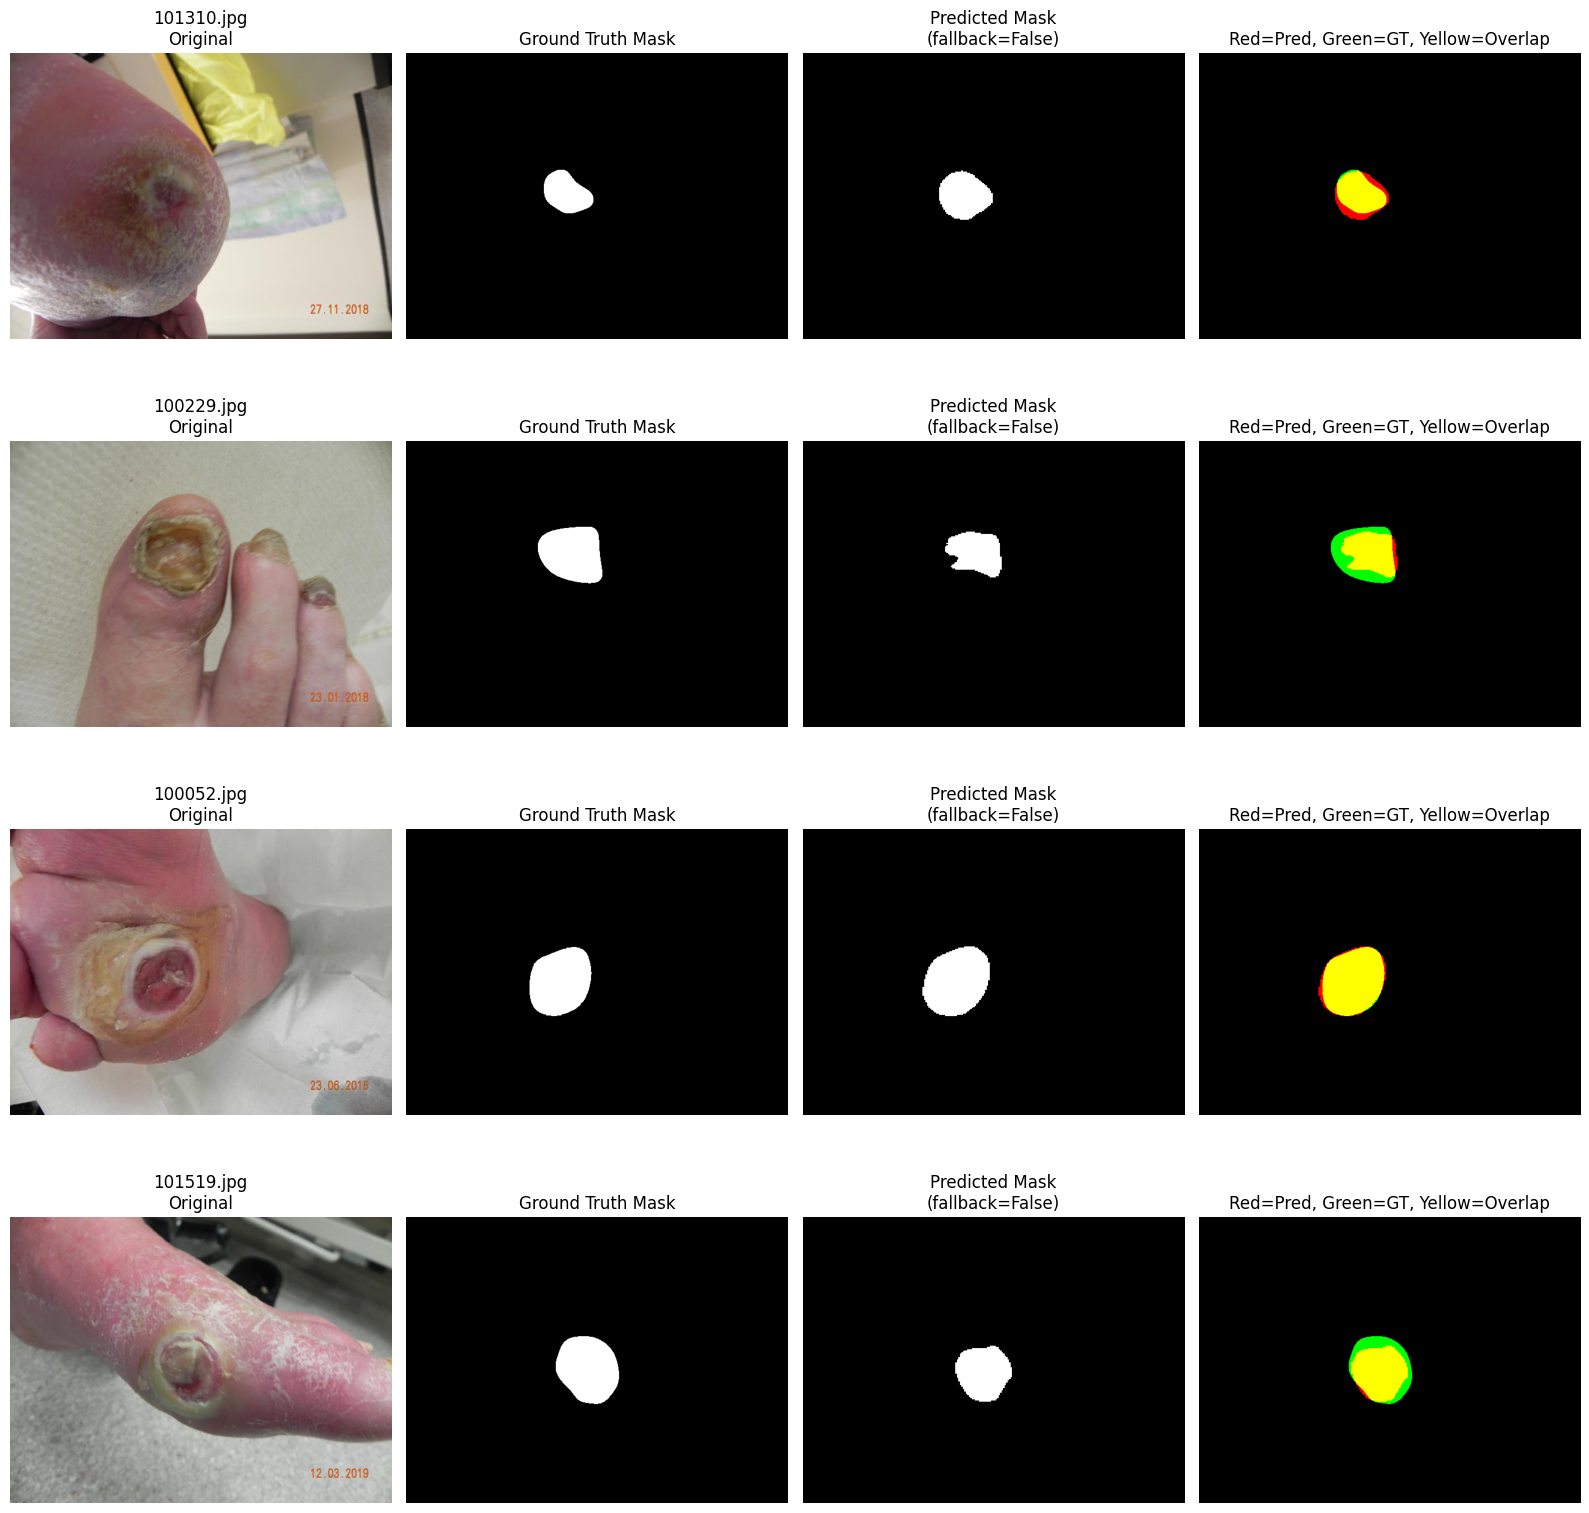

In [16]:
def visualize_pred_vs_gt(n_samples=4, seed=None, threshold=0.5):
    if seed is not None:
        random.seed(seed)
    samples = random.sample(pairs, min(n_samples, len(pairs)))

    fig, axes = plt.subplots(len(samples), 4, figsize=(16, 4 * len(samples)))
    if len(samples) == 1:
        axes = axes[None, :]

    for row, (img_path, mask_path) in enumerate(samples):
        # ---- ground truth (normalized to binary 0/1) ----
        gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        gt_bin = (gt > 127).astype(np.uint8)

        # ---- predicted full mask (uses your existing 4-ch pipeline) ----
        _, _, fell_back, mask_full, _ = predict_mask_and_crop(
            img_path, threshold=threshold, return_extra=True
        )

        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

        # comparison: R=pred, G=GT, yellow=overlap
        comparison = np.zeros((*gt_bin.shape, 3), dtype=np.float32)
        comparison[..., 0] = mask_full.astype(np.float32)
        comparison[..., 1] = gt_bin.astype(np.float32)

        axes[row, 0].imshow(img)
        axes[row, 0].set_title(f'{os.path.basename(img_path)}\nOriginal')

        axes[row, 1].imshow(gt_bin, cmap='gray')
        axes[row, 1].set_title('Ground Truth Mask')

        axes[row, 2].imshow(mask_full, cmap='gray')
        axes[row, 2].set_title(f'Predicted Mask\n(fallback={fell_back})')

        axes[row, 3].imshow(comparison)
        axes[row, 3].set_title('Red=Pred, Green=GT, Yellow=Overlap')

        for ax in axes[row]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

visualize_pred_vs_gt(n_samples=4, seed=42)

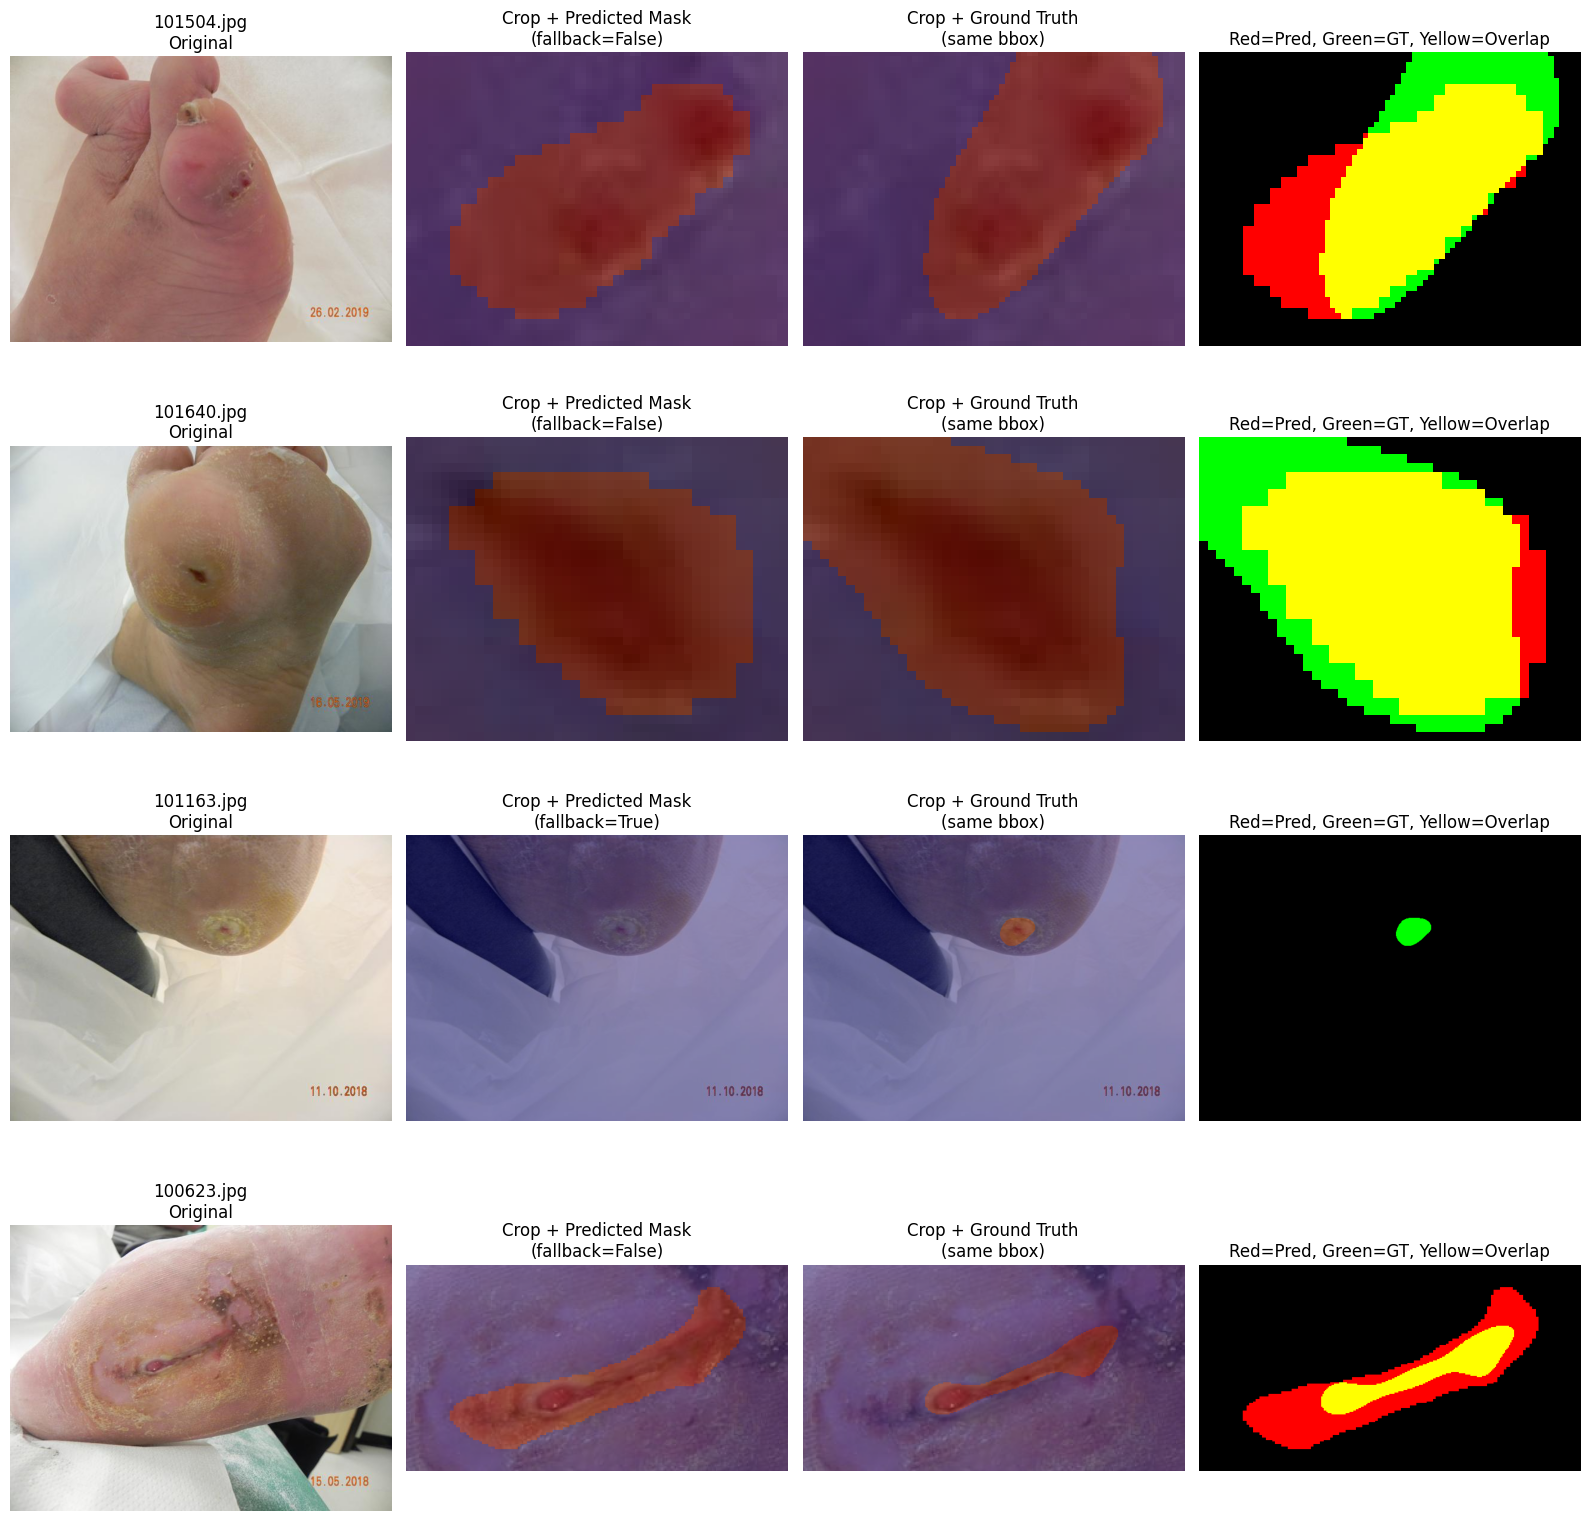

In [20]:
def visualize_crop_batch(n_samples=4, seed=None, threshold=0.5):
    if seed is not None:
        random.seed(seed)
    else:
        random.seed()  

    samples = random.sample(pairs, min(n_samples, len(pairs)))

    fig, axes = plt.subplots(len(samples), 4, figsize=(16, 4 * len(samples)))
    if len(samples) == 1:
        axes = axes[None, :]

    for row, (img_path, mask_path) in enumerate(samples):
        gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        gt_bin = (gt > 127).astype(np.uint8)

        crop_img, crop_mask, fell_back, mask_full, bbox = predict_mask_and_crop(
            img_path, threshold=threshold, return_extra=True
        )

        if bbox is not None:
            x1, y1, x2, y2 = bbox
            gt_crop = gt_bin[y1:y2, x1:x2]
        else:
            gt_crop = gt_bin

        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

        axes[row, 0].imshow(img)
        axes[row, 0].set_title(f'{os.path.basename(img_path)}\nOriginal')

        axes[row, 1].imshow(crop_img)
        axes[row, 1].imshow(crop_mask, cmap='jet', alpha=0.4)
        axes[row, 1].set_title(f'Crop + Predicted Mask\n(fallback={fell_back})')

        axes[row, 2].imshow(crop_img)
        axes[row, 2].imshow(gt_crop, cmap='jet', alpha=0.4)
        axes[row, 2].set_title('Crop + Ground Truth\n(same bbox)')

        comparison = np.zeros((*crop_mask.shape, 3), dtype=np.float32)
        if crop_mask.shape == gt_crop.shape:
            comparison[..., 0] = crop_mask.astype(np.float32)
            comparison[..., 1] = gt_crop.astype(np.float32)
        axes[row, 3].imshow(comparison)
        axes[row, 3].set_title('Red=Pred, Green=GT, Yellow=Overlap')

        for ax in axes[row]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

visualize_crop_batch(n_samples=4, seed=None)

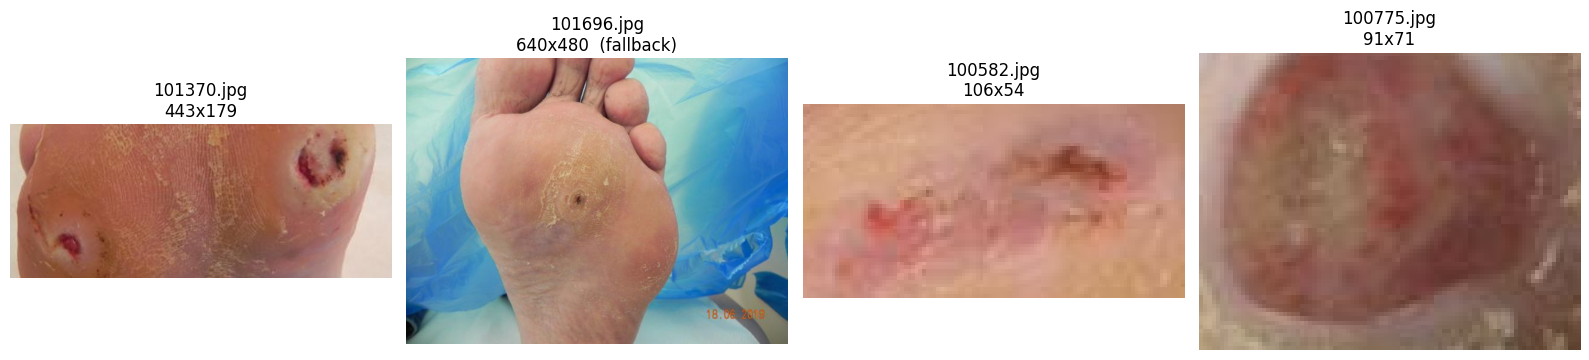

In [22]:
def visualize_final_crops(n_samples=4, seed=None, threshold=0.5):
    if seed is not None:
        random.seed(seed)
    else:
        random.seed()

    samples = random.sample(pairs, min(n_samples, len(pairs)))

    fig, axes = plt.subplots(1, len(samples), figsize=(4 * len(samples), 4))
    if len(samples) == 1:
        axes = [axes]

    for col, (img_path, mask_path) in enumerate(samples):
        crop_img, crop_mask, fell_back, mask_full, bbox = predict_mask_and_crop(
            img_path, threshold=threshold, return_extra=True
        )

        axes[col].imshow(crop_img)
        axes[col].set_title(
            f'{os.path.basename(img_path)}\n{crop_img.shape[1]}x{crop_img.shape[0]}'
            f'{"  (fallback)" if fell_back else ""}'
        )
        axes[col].axis('off')

    plt.tight_layout()
    plt.show()

visualize_final_crops(n_samples=4, seed=None)

Saved cropped image to: /kaggle/working/cropped_regions/302105_jpg.rf.e169fde32344954e45415c78a1ad3a96_crop.jpg
Crop size: 224x224  |  fallback=False


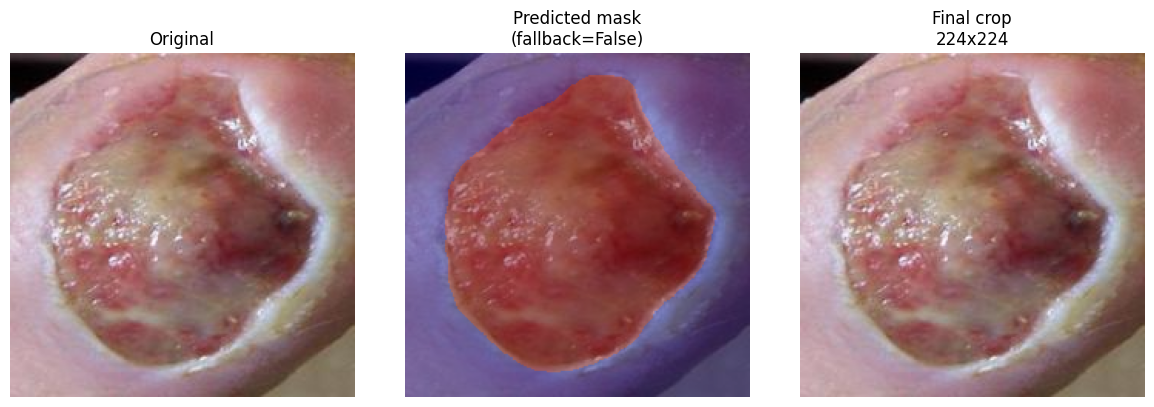

'/kaggle/working/cropped_regions/302105_jpg.rf.e169fde32344954e45415c78a1ad3a96_crop.jpg'

In [64]:
OUTPUT_DIR = '/kaggle/working/cropped_regions'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def crop_and_save_single(img_path, threshold=0.5, output_dir=OUTPUT_DIR, show=True):
    """
    Crop a single image (given its path) using the wound-detection pipeline
    and save the result to output_dir. Optionally displays before/after.
    """
    stem = os.path.splitext(os.path.basename(img_path))[0]

    crop_img, crop_mask, fell_back, mask_full, bbox = predict_mask_and_crop(
        img_path, threshold=threshold, return_extra=True
    )

    # save (convert RGB -> BGR for cv2.imwrite)
    crop_bgr = cv2.cvtColor(crop_img, cv2.COLOR_RGB2BGR)
    out_path = os.path.join(output_dir, f'{stem}_crop.jpg')
    cv2.imwrite(out_path, crop_bgr)

    print(f"Saved cropped image to: {out_path}")
    print(f"Crop size: {crop_img.shape[1]}x{crop_img.shape[0]}  |  fallback={fell_back}")

    if show:
        orig = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(orig)
        axes[0].set_title('Original')
        axes[1].imshow(crop_img)
        axes[1].imshow(crop_mask, cmap='jet', alpha=0.4)
        axes[1].set_title(f'Predicted mask\n(fallback={fell_back})')
        axes[2].imshow(crop_img)
        axes[2].set_title(f'Final crop\n{crop_img.shape[1]}x{crop_img.shape[0]}')
        for ax in axes:
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    return out_path


# Usage: just set the path to the image you want to crop
img_path = "/kaggle/input/datasets/khalidsiddiqui2003/dfu-dataset-annotated-into-4-classes/valid/Grade 3/302105_jpg.rf.e169fde32344954e45415c78a1ad3a96.jpg" 
crop_and_save_single(img_path)

Low-confidence prediction (confidence=55.9%, margin=11.7%). Flagged for manual clinical review rather than an automated dressing recommendation.
{'Grade 1': 3.2759020231828465e-06, 'Grade 2': 0.558666384559278, 'Grade 3': 0.0, 'Grade 4': 0.4413303395386989}


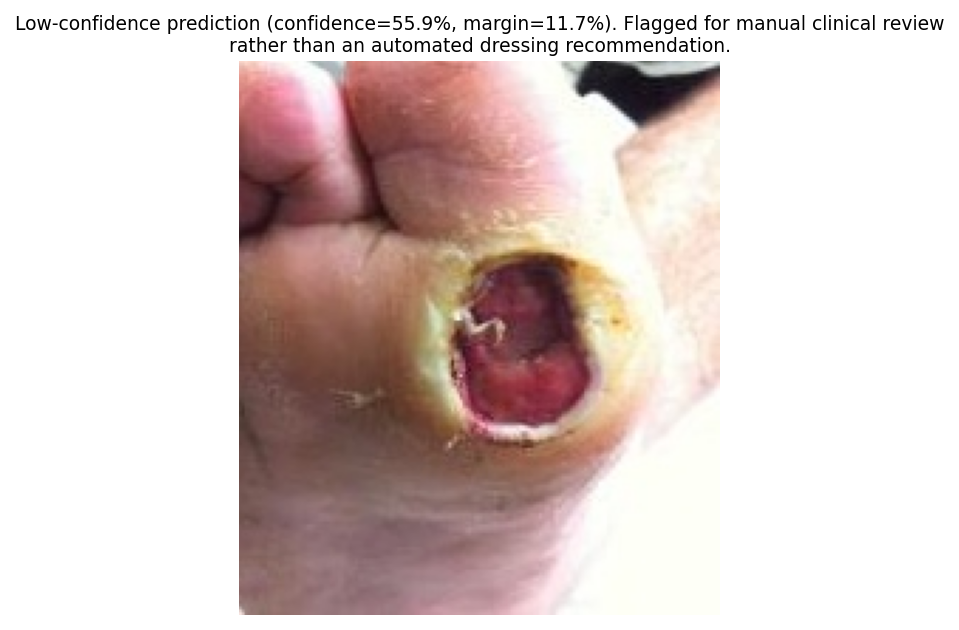

In [63]:
img_path = "/kaggle/working/cropped_regions/diabetic-foot-ulcer-1-_jpg.rf.a2d6920b510df1beb4b59c6d9a61b7b5_crop.jpg"  

img_raw = np.array(Image.open(img_path).convert("RGB"))
img_tensor = eval_transform(image=img_raw)["image"].unsqueeze(0).to(device)

result = predict_and_recommend(model, img_tensor)

print(result["message"])
print(result["class_probabilities"])

plt.imshow(img_raw)
plt.title(result["message"], fontsize=9, wrap=True)
plt.axis("off")
plt.savefig("/kaggle/working/decision_example.png", dpi=150, bbox_inches="tight")
plt.close()
display(IPImage("/kaggle/working/decision_example.png"))